# Funciones básicas para armar ST-DIP

Author: Evelyn Cueva

Created: 2023-09-02


## MapNet con Flax NNX

Mapnet is a fully connected neural network with relu activations. It takes as input coordinate (2D or 3D) and outputs a feature vector of a specified dimension.

In [110]:
import jax
import jax.numpy as jnp
from flax import nnx
from misc_nnx import MapNetNNX

### Ejemplo de uso de MapNetNNX

El siguiente ejemplo recibe un valor $x$ y entrena MapNetNNX para aproximar la función $y = sin(x).$ 

In [111]:
import optax

# === Datos sintéticos: y = sin(x) con algo de ruido ===
key = jax.random.key(0)
x_train = jax.random.uniform(key, (1024, 1), minval=-jnp.pi, maxval=jnp.pi)
y_train = jnp.sin(x_train) + 0.05 * jax.random.normal(jax.random.split(key)[0], x_train.shape)

# === Modelo y optimizador ===
rngs = nnx.Rngs(42)
model = MapNetNNX(in_features=1, hidden_sizes=(64, 64), out_features=1, rngs=rngs)
optimizer = nnx.Optimizer(model, optax.adam(1e-3), wrt=nnx.Param)

# === Función de pérdida ===
def loss_fn(model, xb, yb):
    preds = model(xb) # ocupa la definicion de _call_ del modelo
    return jnp.mean((preds - yb) ** 2)

# === Un paso de entrenamiento ===
def train_step(model, optimizer, xb, yb):
    def _loss(m): # generico, es para la derivacion automática
        return loss_fn(m, xb, yb) #solo depende del modelo, datos de entrenamiento y datos verdaderos
    loss, grads = nnx.value_and_grad(_loss)(model) #calculo de gradientes nada que ver con el optimizador
    optimizer.update(model, grads)  # actualiza los parámetros del modelo in-place con el paso del metodo de descenso (optimizer).
    return loss

# === Loop de entrenamiento simple ===
batch_size = 128
n_steps = 2000

for step in range(1, n_steps + 1):
    # muestreo mini-batch
    k1, key = jax.random.split(key)
    idx = jax.random.choice(k1, x_train.shape[0], (batch_size,), replace=False)
    xb, yb = x_train[idx], y_train[idx]

    l = train_step(model, optimizer, xb, yb)

    if step % 200 == 0:
        print(f"step {step:4d} | loss {float(l):.6f}")

# === Prueba rápida ===
x_test = jnp.linspace(-jnp.pi, jnp.pi, 200).reshape(-1, 1)
y_pred = model(x_test)
print("Pred sample:", y_pred[:5].flatten())

step  200 | loss 0.023537
step  400 | loss 0.004284
step  600 | loss 0.003022
step  800 | loss 0.002937
step 1000 | loss 0.002413
step 1200 | loss 0.002712
step 1400 | loss 0.003301
step 1600 | loss 0.002392
step 1800 | loss 0.002202
step 2000 | loss 0.004112
Pred sample: [-0.0099616  -0.0394522  -0.06894397 -0.09843505 -0.12792608]


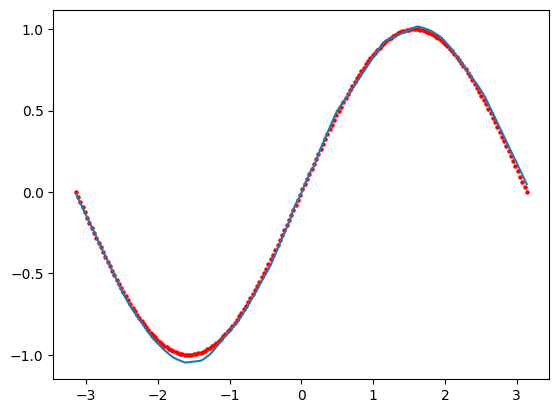

In [112]:
import matplotlib.pyplot as plt

plt.plot(x_test, y_pred, label='Predicción')
plt.scatter(x_test, jnp.sin(x_test), color='r', s=5, label='Verdadero')

## Decoder Net

In [ ]:
import jax, jax.numpy as jnp
from flax import nnx
import optax

### Ejemplo con DecoderNetNNX
Ingresa una matriz de ruido gaussiano de tamaño 8x8 y obtiene una imagen de tamaño 128x128x2.

In [ ]:
from misc_nnx import DecoderNNX

# --------- objetivo sintético suave 128x128x2 ---------
def make_target(H=128, W=128):
    ys = jnp.linspace(-1, 1, H)
    xs = jnp.linspace(-1, 1, W)
    Y, X = jnp.meshgrid(ys, xs, indexing="ij")
    R = jnp.sqrt(X**2 + Y**2)

    # Canal 0: disco gaussiano
    sigma = 0.35
    ch0 = jnp.exp(- (R**2) / (2 * sigma**2))

    # Canal 1: patrón sinusoidal suave
    ch1 = 0.5 * (jnp.sin(3*jnp.pi*X) * jnp.sin(3*jnp.pi*Y)) + 0.5

    target = jnp.stack([ch0, ch1], axis=-1)  # (H, W, 2)
    target = target[None, ...]               # (1, H, W, 2) para NHWC con batch=1
    return target

# --------- setup experimento DIP-like ---------
key = jax.random.key(0)

levels = 3
up = 2
scale_total = up ** (1 + levels)  # 2^(1+3) = 16
H_out = 128
W_out = 128
H_in = H_out // scale_total       # 8
W_in = W_out // scale_total       # 8

assert H_out % scale_total == 0 and W_out % scale_total == 0, "Ajusta niveles o upsampling_factor."

# Entrada (ruido fijo) y objetivo
z = jax.random.normal(key, (1, H_in, W_in, 1))  # NHWC
y_true = make_target(H_out, W_out)              # (1, 128, 128, 2)

# Modelo y optimizador (NNX >= 0.11)
rngs = nnx.Rngs(42)
model = DecoderNNX(in_channels=1, features=64, levels=levels,
                   out_features=2, upsampling_factor=up, rngs=rngs)
optimizer = nnx.Optimizer(model, optax.adam(1e-3), wrt=nnx.Param)

# Pérdida MSE simple
def loss_fn(m: DecoderNNX, z: jax.Array, y: jax.Array):
    yhat = m(z, training=True)
    return jnp.mean((yhat - y) ** 2)

# Un paso de entrenamiento (API nueva: update(model, grads))
def train_step(m: DecoderNNX, opt: nnx.Optimizer, z: jax.Array, y: jax.Array):
    def _loss(m_):
        return loss_fn(m_, z, y)
    loss, grads = nnx.value_and_grad(_loss)(m)
    opt.update(m, grads)
    return loss

# Loop simple
# Sin batch, todo el objetivo a la vez
n_steps = 1500
for step in range(1, n_steps + 1):
    l = train_step(model, optimizer, z, y_true)
    if step % 150 == 0:
        print(f"step {step:4d} | loss {float(l):.6f}")

# Evaluación (usar promedios corridos en BN)
y_pred = model(z, training=False)
print("Output shape:", y_pred.shape, "| min/max:", float(y_pred.min()), float(y_pred.max()))

KeyboardInterrupt: 

(-0.5, 127.5, 127.5, -0.5)

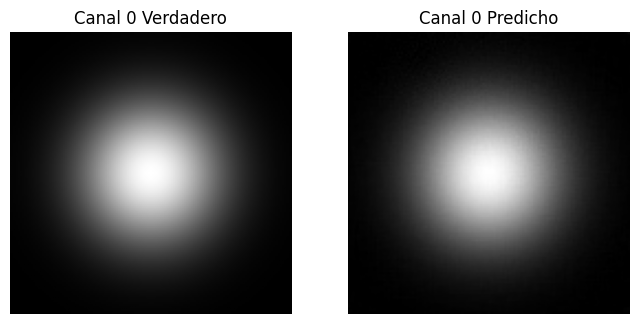

In [7]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(jnp.abs(y_true[0,:,:,0]), cmap='gray')
plt.title("Canal 0 Verdadero")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(jnp.abs(y_pred[0,:,:,0]), cmap='gray')
plt.title("Canal 0 Predicho")
plt.axis('off')

## Unión de MapNeet + Decoder

In [1]:
from typing import Sequence, Tuple, Optional
import jax
import jax.numpy as jnp
from flax import nnx
import optax

In [2]:
import misc_nnx
dir(misc_nnx)


['ConvBNReLU',
 'DecoderNNX',
 'ForwardRadonOperatorJAX',
 'List',
 'MapNetNNX',
 'Optional',
 'RGI',
 'Sequence',
 'TDIPNNX',
 'Tuple',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '_radon_points',
 'as_complex_kspace',
 'complex_mse_weighted',
 'fastshiftfourier',
 'fft',
 'fft1d_shifted',
 'fftshift',
 'ifftshift',
 'interpolate_points_to_grid',
 'jax',
 'jit',
 'jnp',
 'nnx',
 'radon_integration',
 'radon_points',
 'rotate',
 'upsample_2d',
 'vmap',
 'weighted_loss']

### Ejemplo con MapNetNNX + DecoderNNX

Este ejemplo recibe un vector de tiempos $t$ de tamaño $N$ y pasa por MapNetNNx para obtener una espacio latente de $8\times 8$ y luego pasa por DecoderNNX para obtener una imagen de tamaño $N\times128\times 128 \times 2$.


In [ ]:
from misc_nnx import TDIPNNX

# ====== dataset dinámico sintético ======
def make_dyn_target_batch(t_vals: jax.Array, H: int, W: int) -> jax.Array:
    """
    t_vals: (N, 1) en [0,1]
    return: (N, H, W, 2)
    """
    ys = jnp.linspace(-1, 1, H)
    xs = jnp.linspace(-1, 1, W)
    Y, X = jnp.meshgrid(ys, xs, indexing="ij")

    def frame_at_t(t):
        theta = 2 * jnp.pi * t
        cx, cy = 0.3 * jnp.cos(theta), 0.3 * jnp.sin(theta)
        sigma = 0.25
        ch0 = jnp.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * sigma**2))
        # patrón sinusoidal que rota con t
        kx, ky = 3.0, 3.0
        ch1 = 0.5 * (jnp.sin(kx*(X*jnp.cos(theta) - Y*jnp.sin(theta)) + 2*jnp.pi*t) *
                     jnp.sin(ky*(X*jnp.sin(theta) + Y*jnp.cos(theta)) + 2*jnp.pi*t)) + 0.5
        return jnp.stack([ch0, ch1], axis=-1)  # (H, W, 2)

    # vmap sobre la primera dimensión de t_vals
    return jax.vmap(lambda tau: frame_at_t(tau[0]))(t_vals)  # (N, H, W, 2)

# ====== configuración del experimento ======
key = jax.random.key(0)

# Dimensiones
levels = 3
up = 2
scale_total = up ** (1 + levels)  # 2^(1+3)=16
px, py = 8, 8                      # tamaño del "latente imagen" que produce MapNet
H_out, W_out = px * scale_total, py * scale_total  # 128x128
assert H_out == 128 and W_out == 128

# Secuencia temporal
N = 31
t_vals = jnp.linspace(0.0, 1.0, N).reshape(N, 1)   # (N, map_in_features=1)
y_true = make_dyn_target_batch(t_vals, H_out, W_out)  # (N, 128, 128, 2)

# ====== modelo + optimizador (NNX >= 0.11) ======
rngs = nnx.Rngs(42)
model = TDIPNNX(
    map_in_features=1,
    map_hidden_sizes=(64, 64),
    cnn_latent_shape=(px, py),
    decoder_features=64,
    momentum=0.9,
    levels=levels,
    out_features=2,              # 2 canales (p.ej., real/imag)
    upsampling_method="nearest",
    upsampling_factor=up,
    rngs=rngs,
)

optimizer = nnx.Optimizer(model, optax.adam(1e-3), wrt=nnx.Param)

# ====== pérdida y paso de entrenamiento ======
def loss_fn(m: TDIPNNX, t_batch: jax.Array, y_batch: jax.Array):
    yhat = m(t_batch, training=True)
    return jnp.mean((yhat - y_batch) ** 2)

def train_step(m: TDIPNNX, opt: nnx.Optimizer, t_batch: jax.Array, y_batch: jax.Array):
    def _loss(m_):
        return loss_fn(m_, t_batch, y_batch)
    loss, grads = nnx.value_and_grad(_loss)(m)
    opt.update(m, grads)  # API nueva: (model, grads)
    return loss

# ====== loop (full-batch para simplificar) ======
n_steps = 1500
for step in range(1, n_steps + 1):
    l = train_step(model, optimizer, t_vals, y_true)
    if step % 150 == 0:
        print(f"step {step:4d} | loss {float(l):.6f}")

# ====== evaluación (BN en modo inferencia) ======
y_pred = model(t_vals, training=False)
print("y_pred shape:", y_pred.shape, " | min/max:", float(y_pred.min()), float(y_pred.max()))


KeyboardInterrupt: 

#### Visuallización de resultados temporales sintéticos

Dado que la salida del ejemplo tiene dos canales, se visualiza el módulo de la imagen.

In [44]:
# ===== Video helpers para (N, H, W, C) =====
from typing import Literal, Optional
import numpy as np
import imageio.v3 as iio

def prepare_frames_uint8(
    frames: np.ndarray,
    visualization: Literal["magnitude", "channel"] = "magnitude",
    channel: int = 0,
    normalize: Literal["global", "per_frame"] = "global",
) -> np.ndarray:
    """
    Convierte frames (N,H,W,C) -> (N,H,W) uint8 para video.
    - visualization="magnitude": usa sqrt(ch0^2 + ch1^2) (requiere C>=2).
    - visualization="channel": usa un canal específico (channel=0/1/...).
    - normalize="global": mismo contraste para todo el video.
      "per_frame": normaliza cada frame (útil si varía mucho la intensidad).
    """
    arr = np.asarray(frames)  # por si viene como jax.Array
    if arr.ndim == 3:  # (N,H,W) sin canales
        gray = arr
    else:
        assert arr.ndim == 4, f"Se esperaba (N,H,W,C), obtuve {arr.shape}"
        if visualization == "magnitude":
            assert arr.shape[-1] >= 2, "Se requieren >=2 canales para magnitud."
            gray = np.sqrt(arr[..., 0]**2 + arr[..., 1]**2)
        else:  # "channel"
            gray = arr[..., channel]

    if normalize == "global":
        vmin, vmax = float(gray.min()), float(gray.max())
        if vmax <= vmin:
            gray_u8 = np.zeros_like(gray, dtype=np.uint8)
        else:
            gray_u8 = ((gray - vmin) / (vmax - vmin) * 255.0).clip(0, 255).astype(np.uint8)
    else:  # "per_frame"
        N = gray.shape[0]
        gray_u8 = np.empty_like(gray, dtype=np.uint8)
        for i in range(N):
            g = gray[i]
            vmin, vmax = float(g.min()), float(g.max())
            if vmax <= vmin:
                gray_u8[i] = np.zeros_like(g, dtype=np.uint8)
            else:
                gray_u8[i] = ((g - vmin) / (vmax - vmin) * 255.0).clip(0, 255).astype(np.uint8)

    return gray_u8  # (N,H,W), uint8


def save_gif(frames_u8: np.ndarray, path: str = "video.gif", fps: int = 15):
    """
    Guarda GIF animado con imageio (no requiere ffmpeg).
    """
    assert frames_u8.ndim == 3, "Se espera (N,H,W) uint8"
    duration = 1.0 / fps  # seg por frame
    iio.imwrite(path, frames_u8, extension=".gif", duration=duration, loop=0)
    print(f"GIF guardado en: {path}")


In [13]:
# y_pred: (N, H, W, 2)  # p. ej., salida de tu TDIPNNX (2 canales = re/imag)
frames_u8 = prepare_frames_uint8(y_pred, visualization="magnitude", normalize="global")

# GIF (no requiere ffmpeg)
save_gif(frames_u8, "tdip.gif")

GIF guardado en: tdip.gif


In [14]:
frames_u8_true = prepare_frames_uint8(y_true, visualization="magnitude", normalize="global")
save_gif(frames_u8_true, "tdip_true.gif")

GIF guardado en: tdip_true.gif


### Ejemplo con datos reales MRI en numpy

El espacio latente tendrá cierto comportamiento, por ejemplos, puntos de un círculo/hélice/etc. La red es MapNetNNX + DecoderNNX.
Un modelo de T-DIP considera un espacio $k$ sampleado, en este caso, el sampleo es radial. Se incluyen mapas de sensibilidad de las bobinas. Esto cambia principalmente la función de pérdida, que en este caso es la pérdida en el espacio $k$.

#### Cargar los datos disponibles desde el resonador


In [1]:
import jax.numpy as jnp 
from inrmri.radial_acquisitions import RadialAcquisitions
from inrmri.new_radon import get_weight_freqs
from misc_nnx import TDIPNNX

folder = '/home/egcuevaj/repositories/SR-ST-DIP-cMRI/data/Josefa-CineLR/'
print("Loading data...")

data = jnp.load(folder + 'sl5-data.npy')
trajs = jnp.load(folder + 'sl5-traj.npy')
radial_acquisition = RadialAcquisitions(trajs, data)

csmap = jnp.load(folder + 'sl5-csmap.npy')

# Reconstrucción con iterative sense (la reco más básica cuando se conocen las bobinas)
reco_sense = jnp.load(folder + 'sl5-reco-sense.npy')

# Reconstrucción con GRASP (una reco que además de las bobinas incluye regularización (TV en tiempo))
reco_grasp = jnp.load(folder + 'sl5-reco-grasp.npy')

print("Data loaded!")
print(radial_acquisition)
print(f"csmap has shape {csmap.shape}: {csmap.shape[0]} sensitivity maps of size {csmap.shape[1:3]}")
print(f"reco_sense has shape: {reco_sense.shape}: {reco_sense.shape[-1]} frames of size {reco_sense.shape[:2]}")
print(f"reco_grasp has shape: {reco_grasp.shape}: {reco_grasp.shape[-1]} frames of size {reco_grasp.shape[:2]}")

Loading data...
Data loaded!
Radial adquisition: 28 coils, 31 frames of 15 spokes each, 256 samples per spokes.
csmap has shape (28, 256, 256): 28 sensitivity maps of size (256, 256)
reco_sense has shape: (256, 256, 31): 31 frames of size (256, 256)
reco_grasp has shape: (256, 256, 31): 31 frames of size (256, 256)


Se reorganizan los datos para que sean compatibles con el modelo y la función de pérdida. Esto lo realiza la función `radial_acquisition.generate_dataset()`.

Returns
- dataX: Trayectorias de muestreo con información temporal añadida.

         Forma: `(n_frames * n_spokes_per_frame, n_samples + 1, 2)`.

- dataY : Datos de Fourier adquiridos en k-space.
        
         Forma: `(n_frames * n_spokes_per_frame, n_coils, n_samples, 1)`.

In [2]:
print("Creating dataset...")
train_X_full, train_Y = radial_acquisition.generate_dataset()
train_Y = 100 * train_Y  # Escalado de la señal para mantener un orden de magnitud adecuado
print(train_X_full.shape, train_Y.shape)

Creating dataset...
(465, 257, 2) (465, 28, 256, 1)


In [3]:
from inrmri.radial_acquisitions import kFOV_limit_from_spoke_traj, check_correct_dataset

# -------------------------------------------------------------------
# Chequeo de las trayectorias
# -------------------------------------------------------------------
check_correct_dataset(train_X_full)

# Cálculo del límite de FOV a partir de un spoke de ejemplo
spoke_limit = kFOV_limit_from_spoke_traj(train_X_full[0, 1:, :])

# Escalamiento inicial
scaling_param = 1.0

The trajectories are centered


In [4]:
from inrmri.radon import calculate_angle
from jax import vmap
import jax.numpy as jnp

# Los spokes (kx,ky) pueden representarse solo con alpha, se elimina una dimensión usando eso.
angles = vmap(calculate_angle)(train_X_full[:, 1:]) # hay nframes*n_spokes angles
# Tiempos asociados a cada frame (almacenados en la primera columna de cada spoke)
times = train_X_full[:, 0, 1] 
# times = train_X[:, 0, 0] tiene la misma información 
# Nueva representación de entradas: (angle, time)
train_X = jnp.stack([angles, times], axis=-1)
print("New train_X shape:", train_X.shape)  # (nframes*nspokes, 2)

New train_X shape: (465, 2)


In [5]:
# -------------------------------------------------------------------
# Configuración inicial
# -------------------------------------------------------------------
gtim = reco_grasp # es una imagen en cine 31 frames
print(gtim.shape)
NFRAMES = gtim.shape[-1]          # número de frames dinámicos
IMSHAPE = gtim.shape[:2]          # dimensiones espaciales (px, py)
N = IMSHAPE[0]                    # dimensión lateral (asumiendo cuadrado)
total_cycles = 1                  # número total de ciclos cardiacos en la adquisición

(256, 256, 31)


In [6]:
# Grid temporal normalizado (0 a 1, excluyendo el endpoint)
ts = jnp.linspace(0, 1, gtim.shape[-1], endpoint=False)

#### Estructura de la red con NNx

Input: Puntos de una hélice para un ciclo cardíaco (será como un círculo)

In [7]:
# ================== Helix (latente temporal) ==================
def helix_generator(nframes: int, total_cycles: float):
    ts = jnp.linspace(0,total_cycles, nframes, endpoint=False)
    helix = jnp.stack([jnp.cos(2 * jnp.pi * ts), jnp.sin(2 * jnp.pi *ts), ts/total_cycles], axis=-1)
    return helix


helix = helix_generator(NFRAMES, total_cycles) #(31, 3) 
d = helix.shape[1]

def get_latent(latent, t_index):
    """
    Obtiene la representación latente asociada a un frame.

    Parameters
    ----------
    t_index : int or None
        Índice temporal. Si es None, devuelve la latente completa.

    Returns
    -------
    latent : np.ndarray
        Representación latente de forma (N,) o (nframes, N).
    """
    if t_index is None:
        return latent
    return latent[t_index, :]

[-0.44039416  0.89780456  0.32258064]


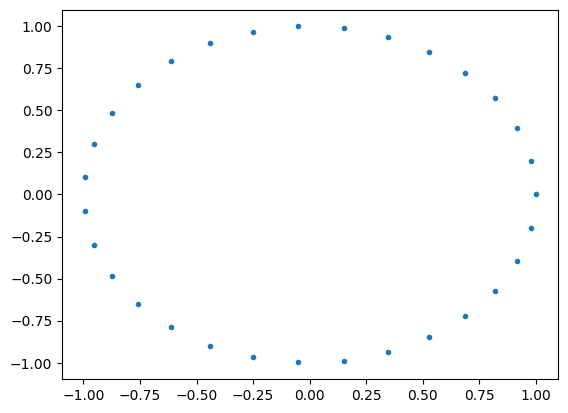

In [8]:
import matplotlib.pyplot as plt
plt.plot(helix[:,0], helix[:,1], '.')
print(helix[10,:])

Vamos a definir la función de pérdida, dado que la pérdida se calcula en el espacio $k$, se usa la transformada de Radon para llegar al espacio de Fourier y comparar con los datos adquiridos (Fourier slice Theorem).

Radon Operator with coils included to use in the loss function 

In [9]:
import jax.numpy as jnp
import jax
from flax import nnx
from jax.scipy.interpolate import RegularGridInterpolator as RGI
from misc_nnx import ForwardRadonOperatorJAX

In [10]:
radon_op = ForwardRadonOperatorJAX(csmap=jnp.asarray(csmap), spclim=0.5, ds=1.0) # se instancia el operador con los coils sensitivity maps

Función de pérdida

In [11]:
from misc_nnx import weighted_loss

# ================== Loss NNX (TDIPNNX con salida Re/Im) ==================
def loss_fn(model: "TDIPNNX",
            X: jnp.ndarray,          # (B, 2): [alpha_rad, time_norm]
            Y: jnp.ndarray,          # (B, C, N) complejo o (B,C,N,1)/(B,C,N,2)
            helix: jnp.ndarray,      # (NFRAMES, d)
            radon_operator: ForwardRadonOperatorJAX,
            weight_freqs: jnp.ndarray):  # (N,)

    alphas = X[:, 0]
    times  = X[:, 1]
    t_idx = jnp.int32(times * NFRAMES)
    latente = helix[t_idx, :]

    # Forward (BN en training=True)
    pred_images = model(latente, training=True)                # (B, H, W, 2)
    pred_images = pred_images[..., 0]  # quitar la dimensión extra de canales → (batch, n, n)

    # Aplicar operador de Radon con ponderación de sensibilidad de coils
    rotated_im = radon_operator.rotated_csweighted_ims(pred_images, alphas)   # (batch, n_coils, N)
    spoke_radon_kspace = radon_operator.radon_transform(rotated_im)          # (batch, n_coils, N)

    # Ground truth: quitar dimensión extra en Y
    target_kspace = Y[..., 0]  # (batch, n_coils, N)
                    # (B, C, N)
    w = (1.0 + weight_freqs)[None, None, :]               # (1,1,N)

    return weighted_loss(spoke_radon_kspace, target_kspace, w)

# ================== Paso de entrenamiento ==================
def make_train_step(radon_op: ForwardRadonOperatorJAX,
                    helix: jnp.ndarray,
                    weight_freqs: jnp.ndarray):
    @nnx.jit 
    def train_step(model: "TDIPNNX", optimizer: nnx.Optimizer, Xb: jnp.ndarray, Yb: jnp.ndarray):
        def _loss(m):
            return loss_fn(m, Xb, Yb, helix, radon_op, weight_freqs)
        loss, grads = nnx.value_and_grad(_loss)(model)
        optimizer.update(model, grads) 
        return loss
    return train_step

# ================== Mini-batching ==================
def sample_minibatch(X: jnp.ndarray, Y: jnp.ndarray, batch_size: int, key: jax.Array):
    n = X.shape[0]
    idx = jax.random.choice(key, n, (batch_size,), replace=False)
    return X[idx], Y[idx]

In [12]:
print(train_X.shape, train_Y.shape)  # (nframes*nspokes, 2), (nframes, C, N) o (nframes, C, N, 1/2)
print(csmap.shape)  # (C, N, N)

(465, 2) (465, 28, 256, 1)
(28, 256, 256)


Entrenamiento

In [13]:
import os
os.environ["XLA_FLAGS"] = os.environ.get("XLA_FLAGS","") + " --xla_gpu_strict_conv_algorithm_picker=false"
# Optional: reduce prealloc to leave headroom for workspaces
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# Now import jax, flax, etc.

In [37]:
# chequear si:
# train_X: (num_spokes, 2) con [alpha_rad, time_norm]
# train_Y: (num_spokes, ncoils, N, 1) complejo   (o (..,2) si Re/Im separados)
# csmap:  (ncoils, N, N) complejo
# WEIGHT_FREQS: (N,)
# TDIPNNX ya definido con out_features=2
import optax
from misc_nnx import ForwardRadonOperatorJAX, TDIPNNX
# 1) Construye operador y latente
NFRAMES = 31
total_cycles = 1.0
helix = helix_generator(NFRAMES, total_cycles)
radon_op = ForwardRadonOperatorJAX(csmap=jnp.asarray(csmap), spclim=0.5, ds=1.0)

# 2) Modelo
rngs = nnx.Rngs(0)
model = TDIPNNX(
    map_in_features=helix.shape[1],   # d = 3 de la hélice
    map_hidden_sizes=(64, 64),
    cnn_latent_shape=(8, 8),          # ajusta según tu decoder: H_out = 8 * 2**(1+levels)
    decoder_features=64,
    momentum=0.9,
    levels=4,
    out_features=2,                   # Re/Im
    upsampling_method="nearest",
    upsampling_factor=2,
    rngs=rngs,
)

# 3) Optimizador 
optimizer = nnx.Optimizer(model, optax.adam(1e-3), wrt=nnx.Param)

# 4) Entrenamiento
WEIGHT_FREQS = get_weight_freqs(N)
train_step = make_train_step(radon_op, helix, jnp.asarray(WEIGHT_FREQS))
 
key = jax.random.key(0)
batch_size = 3
n_steps = 10000

In [38]:
import jax, jax.numpy as jnp
import flax.nnx as nnx

def snapshot_best_params(model):
    # Toma solo los parámetros (nnx.Param) y los convierte a arrays puros
    return nnx.pure(nnx.state(model, nnx.Param))  # -> nnx.State de jax.Array

def restore_params_(model, params_state):
    # Escribe los arrays al modelo (in-place)
    nnx.update(model, params_state)

best_loss   = float("inf")
best_params = None
best_step   = -1

for step in range(1, n_steps + 1):
    key, ks = jax.random.split(key)
    Xb, Yb  = sample_minibatch(jnp.asarray(train_X), jnp.asarray(train_Y), batch_size, ks)

    train_loss_value = train_step(model, optimizer, Xb, Yb)  # actualiza model in-place

    loss_float = float(train_loss_value)
    if loss_float < best_loss:
        best_loss   = loss_float
        best_step   = step
        best_params = snapshot_best_params(model)

    if step % 100 == 0:
        print(f"step {step:4d} | loss {loss_float:.6f} | best@{best_step}={best_loss:.6f}")

# Antes de validar / exportar: restaura el mejor estado
if best_params is not None:
    restore_params_(model, best_params)


step  100 | loss 0.810487 | best@99=0.499936
step  200 | loss 0.704606 | best@113=0.427938
step  300 | loss 0.661038 | best@113=0.427938
step  400 | loss 0.862397 | best@366=0.421872
step  500 | loss 0.622955 | best@478=0.410552
step  600 | loss 0.689701 | best@588=0.404624
step  700 | loss 0.457549 | best@663=0.398154
step  800 | loss 0.621531 | best@750=0.380994
step  900 | loss 0.721967 | best@750=0.380994
step 1000 | loss 0.411777 | best@965=0.372320
step 1100 | loss 0.486430 | best@1042=0.371016
step 1200 | loss 0.622819 | best@1123=0.365530
step 1300 | loss 0.426131 | best@1123=0.365530
step 1400 | loss 0.412847 | best@1363=0.340266
step 1500 | loss 0.438440 | best@1363=0.340266
step 1600 | loss 0.685732 | best@1363=0.340266
step 1700 | loss 0.427547 | best@1363=0.340266
step 1800 | loss 0.585144 | best@1363=0.340266
step 1900 | loss 0.418242 | best@1363=0.340266
step 2000 | loss 0.514639 | best@1363=0.340266
step 2100 | loss 0.385163 | best@1363=0.340266
step 2200 | loss 0.36055

#### Visualización de resultados MRI reales

In [39]:
import jax
import jax.numpy as jnp
import flax.nnx as nnx

def cine_from_params(
    model: "TDIPNNX",
    best_params: nnx.State,          # devuelto por snapshot_best_params(model)
    helix: jnp.ndarray,              # (NFRAMES, d)
    t_idx,                           # (Nt,)
    batch: int
) -> jnp.ndarray:
    """
    Evalúa la cine usando un 'snapshot' de los mejores parámetros (best_params)
    sin modificar permanentemente el estado actual del modelo.

    Pasos:
      1) Guarda los parámetros actuales (nnx.Param) del modelo.
      2) Restaura 'best_params' al modelo (in-place).
      3) Ejecuta inferencia por lotes con BN en modo inferencia (training=False).
      4) Restaura los parámetros originales.

    Retorna:
      predim_cplx: jnp.ndarray de forma (H, W, Nt) en complejo.
    """
    # 1) Guardar params actuales
    current_params = nnx.pure(nnx.state(model, nnx.Param))

    try:
        # 2) Cargar mejores params
        nnx.update(model, best_params)

        # 3) Inferencia por lotes (igual a tu cine_from_trained)
        t_idx = jnp.asarray(t_idx)
        Nt = t_idx.shape[0]

        # Padding para completar batch
        pad = (-Nt) % batch
        if pad:
            t_idx = jnp.concatenate([t_idx, jnp.full((pad,), t_idx[-1])], axis=0)

        # (num_batches, batch)
        stacked_idx = t_idx.reshape(-1, batch)

        def eval_batch(idx_row):
            t_lat = helix[idx_row]                  # (batch, d)
            y = model(t_lat, training=False)        # (batch, H, W, 2) Re/Im
            return y

        y_batched = jax.lax.map(eval_batch, stacked_idx)          # (B, batch, H, W, 2)
        y_full = y_batched.reshape(-1, *y_batched.shape[2:])      # (Nt+pad, H, W, 2)
        y_full = y_full[:Nt]

        y_cplx = y_full[..., 0] + 1j * y_full[..., 1]             # (Nt, H, W)
        predim_cplx = jnp.moveaxis(y_cplx, 0, -1)                 # (H, W, Nt)
        return predim_cplx

    finally:
        # 4) Restaurar params originales del modelo
        nnx.update(model, current_params)


In [ ]:
if best_params is not None:
    predim = cine_from_params(model, best_params, helix, jnp.arange(NFRAMES), batch=5)

In [41]:
from inrmri.utils import is_inside_of_radial_lim, meshgrid_from_subdiv_autolims

# Operador de Radon y grilla espacial
grid = meshgrid_from_subdiv_autolims(IMSHAPE)

# -------------------------------------------------------------------
# Post-procesamiento de reconstrucciones
# -------------------------------------------------------------------
def post_processing(im):
    """
    Aplica una máscara espacial para limitar la reconstrucción
    al dominio válido definido por la adquisición radial.

    Parameters
    ----------
    im : np.ndarray
        Imagen reconstruida.
        Forma: (px, py, nframes)

    Returns
    -------
    np.ndarray
        Imagen postprocesada, con voxeles fuera del FOV puestos en cero.
    """
    # Calcula la máscara booleana de puntos dentro del límite radial
    inside_mask = is_inside_of_radial_lim(grid, 1.0) #radio 1

    # Expande la máscara a lo largo de la dimensión temporal
    return im * inside_mask[:, :, None]
# Se aplica la máscara espacial y se normaliza a [0,1] por magnitud
predim = post_processing(predim) / jnp.abs(predim).max() 

print("Reconstrucción final: ", predim.shape)

Reconstrucción final:  (256, 256, 31)


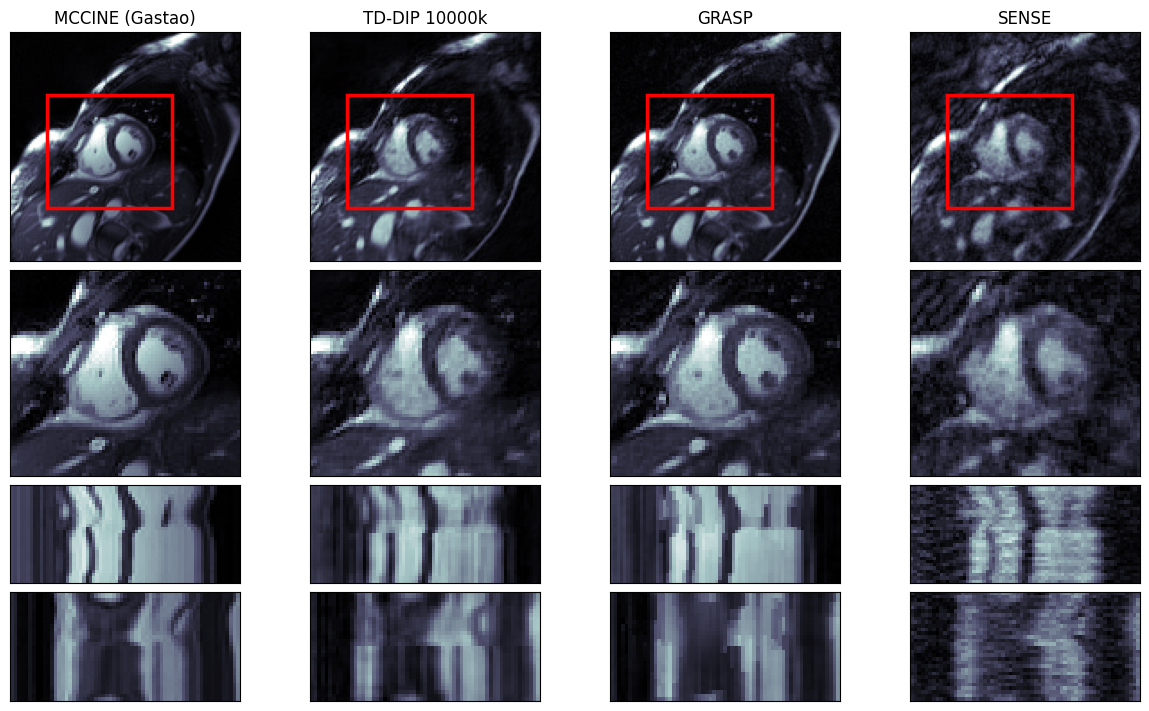

In [ ]:
from inrmri.basic_plotting import full_halph_FOV_space_time
from inrmri.image_processor import BeforeLinRegNormalizer, reduce_crop_abs

crop_ns = [35,30,20,38]
gtim = jnp.load(folder + 'sl5-reco-reference.npy') # 
improc = BeforeLinRegNormalizer(gtim, [0,0,0,0]) # normaliza todas las imagenes a la escala de gtim 

gt_proc = improc.process(gtim)

def final_processing(im):
    im = improc.process(im)
    im = jnp.roll(im, 15, axis=-1) # 15 es el argmin del error con gastao luego de probar todos los rolls 
    return im 
 
# el [1:] es porque gtim solo tiene 30 frames (no 31)
pred_proc = final_processing(predim[...,1:]) 
sense_proc = final_processing(reco_sense[...,1:])
grasp_proc = final_processing(reco_grasp[...,1:])
total_kiter = n_steps
frame = 8 # 8, 23 
vmax = jnp.abs(gtim).max()
recos = [gt_proc, pred_proc, grasp_proc, sense_proc]
titles = ['MCCINE (Gastao)', f'TD-DIP {total_kiter}k', 'GRASP', 'SENSE']
fig, axs = full_halph_FOV_space_time(recos, crop_ns, frame = frame,saturation=0.5, vmax=vmax)
for ax, title in zip(axs, titles):
    ax[0].set_title(title)

In [49]:
predim.shape

(256, 256, 31)